# Librairies 📚

In [2]:
# =========================
# Standard library
# =========================
import os
import sys
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from dython.nominal import (
    associations,
    correlation_ratio,  # eta²
    cramers_v,          # V de Cramér
    theils_u            # Alternative asymétrique
)

# =========================
# Machine Learning
# =========================
import lightgbm as lgb

from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)
from sklearn.svm import SVR

# =========================
# Local imports (src/)
# =========================
sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers_function as of
import src.association_report_function as ar
import src.analyse_bivariee as ab
import src.modeles_comparator as mdl
import src.tunning_parameter as tp
import src.outliers_treatment as ot
import src.fast_modeles_comparator as qc

importlib.reload(of)

# =========================
# Pandas display options
# =========================
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

# Import de la table 🪑

In [3]:
df_backup = pd.read_csv("/home/maxime/projects/building-energy-Seattle/data/processed/data_to_use.csv")
df_backup.drop("Unnamed: 0", axis=1, inplace=True)
df_backup.head(2)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,ListOfAllPropertyUseTypes,LargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,nb_certifications,nb_property_uses,is_mixed_use,building_age,buildings_gfa_ratio,parking_gfa_ratio,largest_use_ratio,gfa_per_building,gfa_per_floor,age_bin,log_gfa,has_gas,has_electricity,has_steam,gas_prop,elec_prop,steam_prop
0,1,NonResidential,Hotel,Mayflower park hotel,405 Olive way,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,Hotel,Hotel,60.00,"7,226,362.50","2,003,882.00","3,946,027.00","1,276,453.00",249.98,0,1,0,89,1.00,0.00,1.00,"88,434.00","7,369.50",80+,11.39,1,1,1,0.18,0.55,0.28
1,2,NonResidential,Hotel,Paramount Hotel,724 Pine street,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,"Hotel, Parking, Restaurant",Hotel,61.00,"8,387,933.00",0.00,"3,242,851.00","5,145,082.00",295.86,0,3,1,20,0.85,0.15,0.81,"103,566.00","9,415.09",0-20,11.55,1,1,0,0.61,0.39,0.00


In [4]:
df = df_backup.copy()
df["CouncilDistrictCode"] = df["CouncilDistrictCode"].astype("category")
df["ZipCode"] = df["ZipCode"].astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   OSEBuildingID                  1527 non-null   int64   
 1   BuildingType                   1527 non-null   str     
 2   PrimaryPropertyType            1527 non-null   str     
 3   PropertyName                   1527 non-null   str     
 4   Address                        1527 non-null   str     
 5   ZipCode                        1514 non-null   category
 6   TaxParcelIdentificationNumber  1527 non-null   str     
 7   CouncilDistrictCode            1527 non-null   category
 8   Neighborhood                   1527 non-null   str     
 9   Latitude                       1527 non-null   float64 
 10  Longitude                      1527 non-null   float64 
 11  YearBuilt                      1527 non-null   int64   
 12  NumberofBuildings              1527 non-null 

# Etape 1 - Preprocessing

## Séparation des colonnes catégoriques et nuémriques

In [ ]:
# J'enlève la certification pour le moment
numeric_features = [
            'Latitude', # tester avec ou sans 
            'Longitude', # tester avec ou sans 

            'NumberofBuildings',
            'NumberofFloors',

            'PropertyGFATotal', # Je le garde et j'utiliserai le log_gfa ensuite

#            'ENERGYSTARScore',

#            'nb_certifications',
            'nb_property_uses',

            "building_age",

            'buildings_gfa_ratio',
            'parking_gfa_ratio',

            'gas_prop',
            'elec_prop',
            'steam_prop'
]

In [ ]:
categorical_features = [
#    'BuildingType',
    'PrimaryPropertyType', 
     # OU #
     'LargestPropertyUseType', # Regrouper les variables
#    'ZipCode',
#    'CouncilDistrictCode',
# Regrouper les variables
#    'ListOfAllPropertyUseTypes' # Supprimer
]

In [ ]:
df["BuildingType"].value_counts() # drop WA 

BuildingType
NonResidential        1424
Nonresidential COS      81
Campus                  21
Nonresidential WA        1
Name: count, dtype: int64

## Preprocessing

In [10]:
col_sel = numeric_features + categorical_features
X = df[col_sel]
y_energy = df["SiteEnergyUse(kBtu)"] # df["log_SiteEnergyUse"]

y_ghg = df["TotalGHGEmissions"] # df["log_TotalGHG"]

In [11]:
X = X.copy()
X.columns = X.columns.astype(str)
numeric_features = [c for c in map(str, numeric_features) if c in X.columns]
categorical_features = [c for c in map (str, categorical_features) if c in X.columns]
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Latitude                   1527 non-null   float64 
 1   Longitude                  1527 non-null   float64 
 2   YearBuilt                  1527 non-null   int64   
 3   NumberofBuildings          1527 non-null   float64 
 4   NumberofFloors             1527 non-null   int64   
 5   PropertyGFATotal           1527 non-null   int64   
 6   ENERGYSTARScore            980 non-null    float64 
 7   nb_certifications          1527 non-null   int64   
 8   nb_property_uses           1527 non-null   int64   
 9   building_age               1527 non-null   int64   
 10  buildings_gfa_ratio        1527 non-null   float64 
 11  parking_gfa_ratio          1527 non-null   float64 
 12  gas_prop                   1527 non-null   float64 
 13  elec_prop                  1527 non-null   f

In [12]:
seed = 42
preprocessor = mdl.make_preprocessor(numeric_features, categorical_features)

## Séparation en test train split

In [13]:
X_train, X_test, y_train, y_test = mdl.split_data(X, y_ghg, test_size=0.2, seed=seed)

# Première comparaison modèle

In [14]:
models = [ 
    ("dummy_mean", DummyRegressor(strategy="mean")), 
    ("linear_regression", LinearRegression()), 
    ("elastic_net", ElasticNet(random_state=seed)), 
    ("svr", SVR()), 
    ("random_forest", RandomForestRegressor( random_state=seed, n_estimators=200, n_jobs=-1 )), 
    ("lgbm", lgb.LGBMRegressor(random_state=seed, verbosity=-1)), 
    ("xgboost", XGBRegressor( random_state=seed, n_estimators=200, n_jobs=-1 )) 
]

In [15]:
rf = RandomForestRegressor(random_state=42, n_estimators=200)

pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf)
])

rmse_cv = qc.quick_cv(pipe, X_train, y_train)
print("RF CV RMSE:", rmse_cv)

Durée d'exécution de quick_cv: 3.447s
RF CV RMSE: 289.4166225020832


In [16]:
results = []

for name, model in models:
    
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    rmse_cv = qc.quick_cv(pipe, X_train, y_train)
    
    results.append({
        "model": name,
        "cv_rmse": rmse_cv
    })

results_df = pd.DataFrame(results).sort_values("cv_rmse")
results_df

Durée d'exécution de quick_cv: 0.999s
Durée d'exécution de quick_cv: 1.102s
Durée d'exécution de quick_cv: 0.833s
Durée d'exécution de quick_cv: 0.167s
Durée d'exécution de quick_cv: 1.318s


/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegress

Durée d'exécution de quick_cv: 141.718s
Durée d'exécution de quick_cv: 3.283s


,model,cv_rmse
5,lgbm,261.03
4,random_forest,289.42
6,xgboost,311.25
2,elastic_net,325.88
1,linear_regression,381.40
0,dummy_mean,390.33
3,svr,398.42


In [17]:
y_train.mean(), y_train.std()

(np.float64(159.6817035217035), np.float64(401.9468838100833))

## Conclusion – Première comparaison de modèles

Nous avons comparé plusieurs modèles de régression via une validation croisée à 5 folds en utilisant le **RMSE** comme métrique d’évaluation.

### Résultats principaux

* Le modèle naïf (`DummyRegressor`) obtient un RMSE ≈ **390.33**
* Les modèles linéaires réduisent l’erreur à environ **261.03**
* Les modèles basés sur les arbres performent nettement mieux :

  * Light GBM ≈ **261.03** (meilleur modèle à ce stade)
  * Random Forest ≈ **289.42** 

Cela représente une **réduction d’erreur d’environ 67 % par rapport au modèle naïf**, ce qui indique que les variables explicatives capturent une part importante de la variance de la cible.

---

### Analyse de la variable cible

La variable cible présente :

* Moyenne ≈ **159.68**
* Écart-type ≈ **401.94**

L’écart-type étant plus de deux fois supérieur à la moyenne, la distribution est fortement asymétrique avec une **queue lourde (heavy tail)**.
Ce comportement est typique des données sur les émissions carbones : quelques bâtiments très énergivores influencent fortement la variance globale.

Cela explique :

* Un RMSE élevé en valeur absolue
* La supériorité des modèles non linéaires (arbres de décision)

---

### Interprétation

1. Les modèles linéaires sont limités face à la non-linéarité et à l’hétéroscédasticité.
2. Les modèles d’ensemble (Random Forest, XGBoost) capturent mieux :

   * les interactions
   * les effets seuil
   * la structure non linéaire des données.
3. Les performances obtenues sont cohérentes avec la structure statistique de la cible.

---

### Prochaine étape logique

* Stabiliser la variance et réduire l’influence des valeurs extrêmes en transformant la taget en log1p
* Se concentrer sur les modèles qui performent le plus : random_forest et XGBoost

# Transformation de la target en log1p

In [18]:
def make_log_model(model):
    return TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

In [19]:
models_log = [
    ("dummy_mean", make_log_model(DummyRegressor(strategy="mean"))),
    ("linear_regression", make_log_model(LinearRegression())),
    ("elastic_net", make_log_model(ElasticNet(random_state=seed))),
    ("svr", make_log_model(SVR())),
    ("random_forest", make_log_model(
        RandomForestRegressor(random_state=seed, n_estimators=200)
    )),
    ("lgbm", make_log_model(
        lgb.LGBMRegressor(random_state=seed, verbosity=-1)
    )),
    ("xgboost", make_log_model(
        XGBRegressor(random_state=seed, n_estimators=200)
    ))
]

In [20]:
results_log = []

for name, model in models_log:
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    rmse = qc.quick_cv(pipe, X_train, y_train)
    results_log.append((name, rmse))

results_log = pd.DataFrame(results_log, columns=["model", "cv_rmse"])
results_log.sort_values("cv_rmse")

Durée d'exécution de quick_cv: 1.189s
Durée d'exécution de quick_cv: 1.033s
Durée d'exécution de quick_cv: 0.959s
Durée d'exécution de quick_cv: 0.918s
Durée d'exécution de quick_cv: 1.711s


/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegress

Durée d'exécution de quick_cv: 157.336s
Durée d'exécution de quick_cv: 2.846s


,model,cv_rmse
5,lgbm,243.89
4,random_forest,251.20
6,xgboost,267.85
3,svr,302.15
2,elastic_net,397.03
0,dummy_mean,404.12
1,linear_regression,"81,497.29"


La transformation logarithmique de la cible n'améliore pas les performances des modèles basés sur les arbres, ce qui suggère que ces modèles capturent déjà efficacement la non-linéarité et la forte asymétrie de la distribution.

# Comparaison des meilleurs modèles

In [18]:
mdl.make_preprocessor(numeric_features, categorical_features, sparse_output=False)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [19]:
X_train, X_test, y_train, y_test = mdl.split_data(X, y_energy, test_size=0.2, seed=42)

In [20]:
models = [
    ("random_forest", RandomForestRegressor(random_state=42, n_estimators=400, n_jobs=-1)),
    ("xgboost", XGBRegressor(
        random_state=42,
        n_estimators=600,
        learning_rate=0.05,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1
    )),
]

In [21]:
param_grids = {
    "random_forest": {
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 10],
        "min_samples_leaf": [1, 5],
        "max_features": ["sqrt", 0.5],
    },
    "xgboost": {
        "max_depth": [4, 6, 8],
        "subsample": [0.7, 1.0],
        "colsample_bytree": [0.7, 1.0],
        "reg_lambda": [1, 5, 10],
        "min_child_weight": [1, 5, 10],
    }
}

In [22]:
results_raw = mdl.compare_models(
    models=models,
    param_grids=param_grids,
    preprocessor=preprocessor,
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    use_log_target=False,   # vu tes tests : mieux en brut
    cv=5,
    seed=42
)

results
results = pd.concat([results_raw], ignore_index=True)\
            .sort_values(["RMSE", "MAE"], ascending=True)

results

Durée d'exécution de cross_validation: 17.052s
Durée d'exécution de cross_validation: 36.529s
Durée d'exécution de compare_models: 53.678s


,model,use_log_target,cv_rmse,r2,MAE,MSE,RMSE,best_params,estimator
0,random_forest,False,"7,953,795.96",0.71,"2,716,910.76","40,213,403,364,829.34","6,341,403.90","{'model__max_depth': None, 'model__max_feature...","(ColumnTransformer(transformers=[('num',\n ..."
1,xgboost,False,"7,586,205.14",0.68,"2,793,582.71","44,606,272,176,434.73","6,678,792.72","{'model__colsample_bytree': 1.0, 'model__max_d...","(ColumnTransformer(transformers=[('num',\n ..."


In [23]:
results.to_csv("/home/maxime/projects/building-energy-Seattle/data/processed/results_v1.csv")

# Comparaison des meilleures modèles avec meilleurs paramètres

In [24]:
param_grids = {
    "random_forest": {
        "max_depth": [None, 15, 25],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 3, 5],
        "max_features": [0.4, 0.5, 0.6],
        "n_estimators": [400, 800]
    },
    "xgboost": {
        "max_depth": [5, 6, 7],
        "learning_rate": [0.03, 0.05, 0.08],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "min_child_weight": [1, 3, 5],
        "reg_lambda": [1, 5, 10],
        "n_estimators": [600, 900]
    }
}

In [25]:
results_raw = mdl.compare_models(
    models=models,
    param_grids=param_grids,
    preprocessor=preprocessor,
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    use_log_target=False,   # vu tes tests : mieux en brut
    cv=5,
    seed=42
)

results
results = pd.concat([results_raw], ignore_index=True)\
            .sort_values(["RMSE", "MAE"], ascending=True)

results

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/maxime/miniconda3/envs/ds/lib/python3.11

Durée d'exécution de cross_validation: 417.119s


/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Durée d'exécution de cross_validation: 489.746s
Durée d'exécution de compare_models: 906.983s


,model,use_log_target,cv_rmse,r2,MAE,MSE,RMSE,best_params,estimator
0,random_forest,False,"7,844,999.61",0.71,"2,753,689.27","40,712,885,791,584.18","6,380,665.00","{'model__max_depth': 25, 'model__max_features'...","(ColumnTransformer(transformers=[('num',\n ..."
1,xgboost,False,"7,402,616.83",0.68,"2,818,931.45","44,907,064,247,629.57","6,701,273.33","{'model__colsample_bytree': 1.0, 'model__learn...","(ColumnTransformer(transformers=[('num',\n ..."


In [26]:
results.to_csv("/home/maxime/projects/building-energy-Seattle/data/processed/results_v2.csv")

In [27]:
results[["model", "cv_rmse", "RMSE", "r2"]]

,model,cv_rmse,RMSE,r2
0,random_forest,"7,844,999.61","6,380,665.00",0.71
1,xgboost,"7,402,616.83","6,701,273.33",0.68


In [28]:
rf_rmse = results.loc[
    results["model"] == "random_forest", "RMSE"
].values[0]

xgb_rmse = results.loc[
    results["model"] == "xgboost", "RMSE"
].values[0]

diff_test = abs(rf_rmse - xgb_rmse)

print(f"Différence test RMSE: {diff_test:,.0f}")
print(f"Différence relative: {100*diff_test/min(rf_rmse, xgb_rmse):.2f}%")

Différence test RMSE: 320,608
Différence relative: 5.02%


In [29]:
results["cv_test_gap"] = (
    results["cv_rmse"] - results["RMSE"]
)

results[["model", "cv_rmse", "RMSE", "cv_test_gap"]]

,model,cv_rmse,RMSE,cv_test_gap
0,random_forest,"7,844,999.61","6,380,665.00","1,464,334.61"
1,xgboost,"7,402,616.83","6,701,273.33","701,343.50"


Bien que XGBoost obtienne un score légèrement meilleur en validation croisée, le Random Forest présente de meilleures performances sur le jeu de test (RMSE inférieur de 5%). Ce modèle est donc retenu pour sa meilleure capacité de généralisation.

# Variables les plus importantes

In [31]:
best_rf = results.loc[results["model"] == "random_forest", "estimator"].iloc[0]

preproc = best_rf.named_steps["preprocessing"]
feature_names = preproc.get_feature_names_out()

len(feature_names), feature_names[:10]

(468,
 array(['num__Latitude', 'num__Longitude', 'num__YearBuilt',
        'num__NumberofBuildings', 'num__NumberofFloors',
        'num__PropertyGFATotal', 'num__ENERGYSTARScore',
        'num__nb_certifications', 'num__nb_property_uses',
        'num__building_age'], dtype=object))

In [32]:
rf_model = best_rf.named_steps["model"]

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
5,num__PropertyGFATotal,0.50
4,num__NumberofFloors,0.06
102,cat__LargestPropertyUseType_Hospital (General ...,0.05
20,cat__PrimaryPropertyType_Hospital,0.05
12,num__gas_prop,0.04
13,num__elec_prop,0.04
6,num__ENERGYSTARScore,0.03
8,num__nb_property_uses,0.01
0,num__Latitude,0.01
252,cat__ListOfAllPropertyUseTypes_Hospital (Gener...,0.01


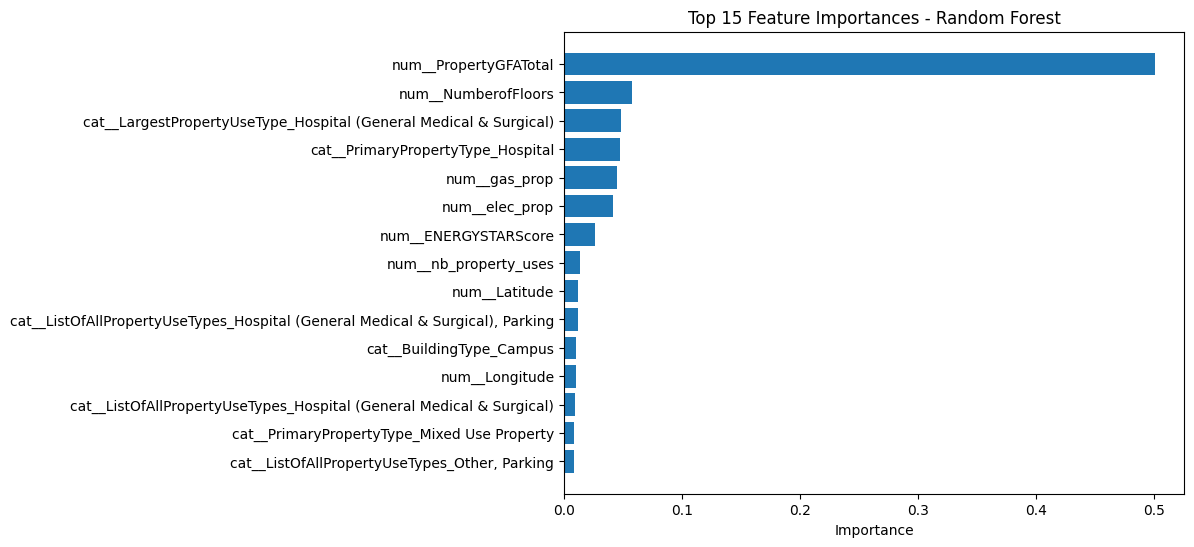

In [33]:
top_n = 15
top_features = feat_imp.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"][::-1], 
         top_features["importance"][::-1])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

In [ ]:
preproc = best_rf.named_steps["preprocessing"]
feature_names = preproc.get_feature_names_out()

perm = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

print("n_features (names):", len(feature_names))
print("n_features (perm): ", len(perm.importances_mean))

n_features (names): 468
n_features (perm):  21


## A) Importance au niveau des features brutes

In [37]:
perm = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_rmse": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance_rmse", ascending=False)

perm_df.head(20)

,feature,importance_rmse,std
5,PropertyGFATotal,"9,442,175.65","837,907.52"
12,gas_prop,"398,562.65","215,534.28"
6,ENERGYSTARScore,"250,833.36","102,729.86"
13,elec_prop,"130,147.53","121,969.76"
4,NumberofFloors,"86,625.06","35,762.96"
16,PrimaryPropertyType,"41,362.14","64,617.09"
10,buildings_gfa_ratio,"36,149.34","7,024.21"
11,parking_gfa_ratio,"33,995.68","6,368.05"
8,nb_property_uses,"24,261.97","35,268.97"
0,Latitude,"15,074.95","16,018.92"


## B) Importance au niveau des features transformées

In [38]:
rf_model = best_rf.named_steps["model"]
preproc = best_rf.named_steps["preprocessing"]
X_test_tr = preproc.transform(X_test)

feature_names = preproc.get_feature_names_out()

perm = permutation_importance(
    rf_model, X_test_tr, y_test,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_rmse": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance_rmse", ascending=False)

perm_df.head(20)

,feature,importance_rmse,std
5,num__PropertyGFATotal,"9,442,175.65","837,907.52"
12,num__gas_prop,"398,562.65","215,534.28"
6,num__ENERGYSTARScore,"250,833.36","102,729.86"
13,num__elec_prop,"130,147.53","121,969.76"
4,num__NumberofFloors,"86,625.06","35,762.96"
36,cat__PrimaryPropertyType_Supermarket / Grocery...,"59,123.40","7,230.17"
23,cat__PrimaryPropertyType_Laboratory,"58,371.84","6,752.18"
105,cat__LargestPropertyUseType_Laboratory,"57,506.40","10,639.30"
10,num__buildings_gfa_ratio,"36,149.34","7,024.21"
11,num__parking_gfa_ratio,"33,995.68","6,368.05"


## Conclusion - Variables les plus influentes

L’analyse de permutation importance met clairement en évidence :

 1. PropertyGFATotal (surface totale)

Variable de très loin la plus importante.

→ Logique métier : plus un bâtiment est grand, plus sa consommation est élevée.
→ Confirme que la surface est le principal déterminant structurel.

 2. Proportions énergétiques (gas_prop, elec_prop, steam_prop)

Les parts relatives des différentes sources d’énergie sont fortement contributives.

→ Le mix énergétique influence fortement la consommation totale.

 3. ENERGY STAR Score

Score d’efficacité énergétique significatif.

→ Indique que les bâtiments plus performants énergétiquement consomment effectivement moins.
*
 4. Nombre d’étages (NumberofFloors)

Impact structurel lié à la volumétrie.

 5. Type de bâtiment (PrimaryPropertyType, LargestPropertyUseType)

Certaines catégories (Laboratory, Supermarket, Warehouse, etc.) ressortent comme particulièrement déterminantes.

→ Confirme l’importance de l’usage fonctionnel dans la consommation énergétique.

# Analyse des erreurs (où le modèle se trompe)

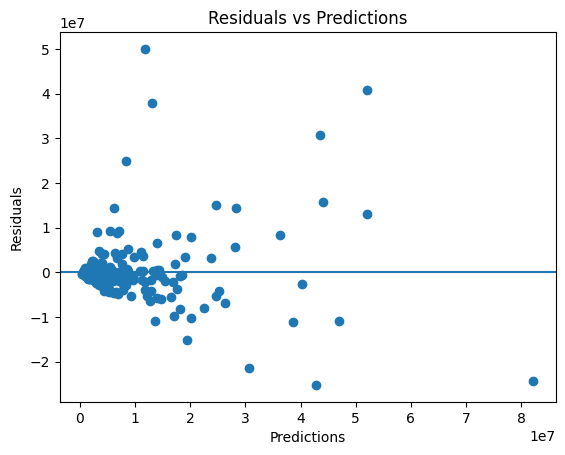

In [41]:
y_pred = best_rf.predict(X_test)

residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

In [66]:
error_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "abs_error": abs(residuals)
})
error_df["pct_error"] = abs(residuals) / y_test

error_df.sort_values("abs_error", ascending=False).head(10)

,y_true,y_pred,abs_error,pct_error
270,"61,762,380.00","11,733,659.74","50,028,720.26",0.81
490,"92,937,640.00","52,032,060.23","40,905,579.77",0.44
1494,"51,168,308.00","13,156,316.79","38,011,991.21",0.74
415,"74,130,576.00","43,479,951.48","30,650,624.52",0.41
244,"17,666,646.00","42,877,373.58","25,210,727.58",1.43
621,"33,268,410.00","8,385,913.75","24,882,496.25",0.75
1463,"57,764,408.00","82,186,599.57","24,422,191.57",0.42
843,"9,155,568.00","30,677,005.39","21,521,437.39",2.35
115,"59,757,440.00","44,107,223.63","15,650,216.37",0.26
76,"4,253,577.50","19,378,520.78","15,124,943.28",3.56


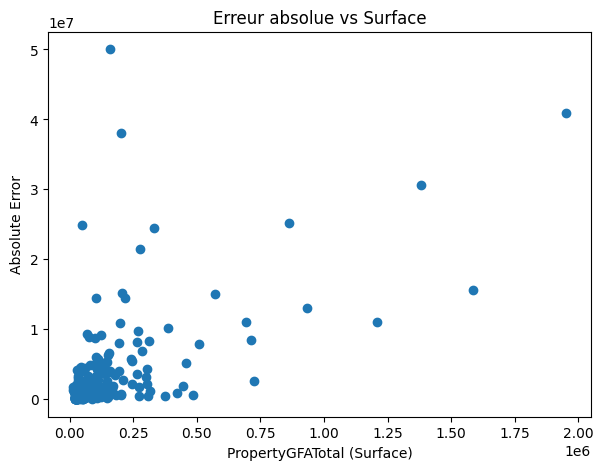

In [67]:
analysis_df = X_test.copy()
analysis_df["y_true"] = y_test
analysis_df["y_pred"] = y_pred
analysis_df["abs_error"] = np.abs(analysis_df["y_true"] - analysis_df["y_pred"])

plt.figure(figsize=(7,5))
plt.scatter(
    analysis_df["PropertyGFATotal"],
    analysis_df["abs_error"]
)
plt.xlabel("PropertyGFATotal (Surface)")
plt.ylabel("Absolute Error")
plt.title("Erreur absolue vs Surface")
plt.show()

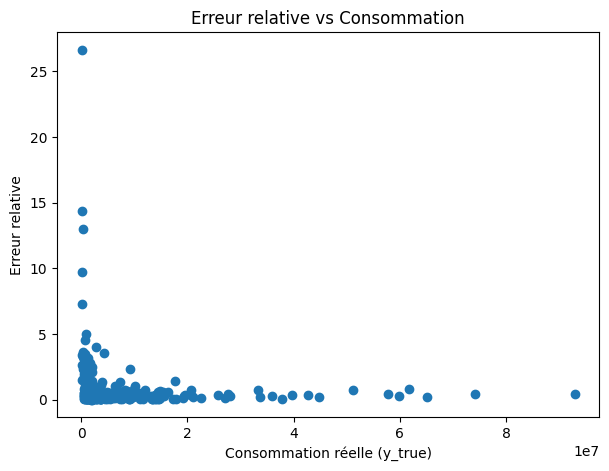

In [73]:
analysis_df["pct_error"] = (
    analysis_df["abs_error"] / 
    (np.abs(analysis_df["y_true"]) + 1e-6)
)

plt.figure(figsize=(7,5))
plt.scatter(
    analysis_df["y_true"],
    analysis_df["pct_error"]
)
plt.xlabel("Consommation réelle (y_true)")
plt.ylabel("Erreur relative")
plt.title("Erreur relative vs Consommation")
plt.show()

In [74]:
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
rmsle

np.float64(0.6819317231228826)

In [75]:
segment_perf = (
    analysis_df
    .groupby("PrimaryPropertyType")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_pct_error=("pct_error", "mean"),
        count=("y_true", "count")
    )
    .sort_values("mean_abs_error", ascending=False)
)

segment_perf.head(10)

,mean_abs_error,mean_pct_error,count
PrimaryPropertyType,,,
Hospital,"24,422,191.57",0.42,1
Laboratory,"11,521,559.28",0.42,3
University,"11,124,578.27",1.00,6
Senior Care Community,"6,028,690.95",0.80,7
Low-Rise Multifamily,"4,938,311.71",2.47,1
Large Office,"4,830,341.52",0.37,35
Retail Store,"3,776,061.49",0.69,14
Other,"3,711,153.46",1.20,48
Mixed Use Property,"3,576,791.26",0.51,21


In [80]:
def scores(y_pred, y_true):
    r2 = r2_score(y_true, y_pred) 
    mae = mean_absolute_error(y_true, y_pred) 
    mse = mean_squared_error(y_true, y_pred) 
    rmse = mean_squared_log_error(y_true, y_pred) 
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {
        "r2": float(r2),
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "MAPE": float(rmse)
    }


In [81]:
scores(y_pred,y_test)

{'r2': 0.7088913960408133,
 'MAE': 2753689.2653648793,
 'MSE': 40712885791584.18,
 'RMSE': 0.46503087500134394,
 'MAPE': 0.46503087500134394}

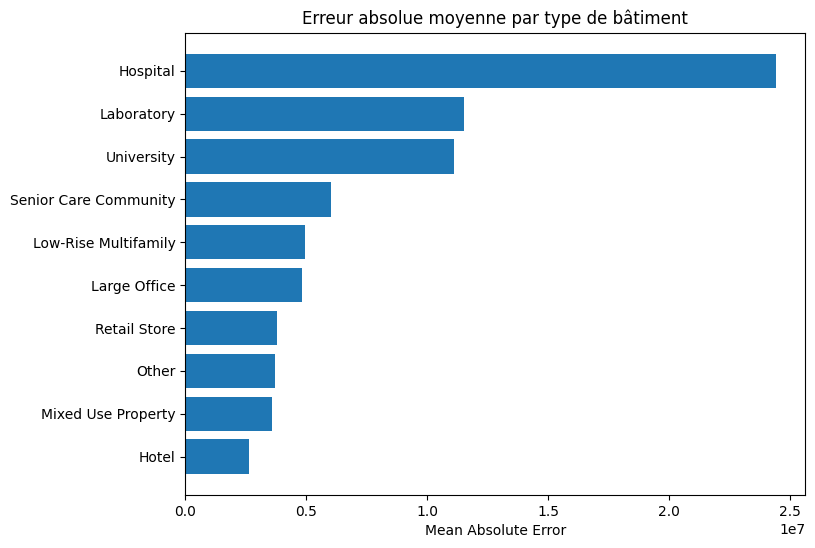

In [48]:
top_segments = segment_perf.head(10)

plt.figure(figsize=(8,6))
plt.barh(
    top_segments.index[::-1],
    top_segments["mean_abs_error"][::-1]
)
plt.title("Erreur absolue moyenne par type de bâtiment")
plt.xlabel("Mean Absolute Error")
plt.show()

## Conclusion - Évaluation des performances

L’analyse des erreurs montre que :

- Les plus fortes erreurs absolues concernent les bâtiments à très forte consommation énergétique.

- Les plus fortes erreurs relatives concernent les bâtiments à faible consommation.

Le modèle tend à **sous-estimer les valeurs extrêmes**, phénomène classique avec des données fortement asymétriques.

Le RMSLE (≈ 0.68) indique que l’erreur proportionnelle reste maîtrisée malgré la présence d’une heavy-tail.

Ainsi, le modèle présente :

- Une bonne capacité explicative globale (R² ≈ 0.71)

- Une performance robuste en moyenne

- Des limites naturelles sur les extrêmes